# Dataset Visualization and Balancing
This notebook analyzes the final evaluation dataset before conducting LLM experiments.

The notebook performs the following tasks:

- Load the processed dataset
- Analyze class distribution
- Analyze flaky category distribution
- Visualize dataset characteristics
- Balance the dataset (if required)
- Save the balanced evaluation dataset

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.utils import resample

plt.style.use("ggplot")

In [3]:
DATASET_PATH = Path("../../datasets/evaluation_dataset.jsonl")

df = pd.read_json(DATASET_PATH, lines=True)

print(f"Total Samples : {len(df)}")
df.head()

Total Samples : 2741


,id,test_id,isFlaky,issue_category,repo_url,issue_commit,fixed_commit,test_code,helper_methods_json,failure_log,code_under_test_json,test_code_original,helper_methods_json_original,failure_log_original,code_under_test_original
0,1,apollojavaapolloopenapi5344bc4testFindItemsByN...,True,Implementation Dependent,https://github.com/apolloconfig/apollo-java,5344bc4f07288842bb850145bcf80a084bd94114,21259e5dcef3960b2162ae9c62b6acd6b99e59fd,@Test\n public void testFindItemsByNamespace(...,{},org.junit.ComparisonFailure: expected:<...some...,{'com.ctrip.framework.apollo.openapi.client.se...,@Test\n public void testFindItemsByNamespace(...,{},Failed Rounds: 53/101\norg.junit.ComparisonFai...,{'com.ctrip.framework.apollo.openapi.client.se...
1,2,fastjson97ee7b6test_for_issue5,True,Implementation Dependent,https://github.com/alibaba/fastjson,97ee7b63bfd1563d5071fa5a7a55806bb1c3cb85,0f4379b58cc54e8e4429770f32f8e1c86202a028,public void test_for_issue() throws Exception ...,{},"org.junit.ComparisonFailure: expected:<{[1:10,...",{'com.alibaba.fastjson.JSON': {'parseObject': ...,public void test_for_issue() throws Exception ...,{},Failed Rounds: 100/101\norg.junit.ComparisonFa...,{'com.alibaba.fastjson.JSON': {'parseObject': ...
2,3,fastjson194b299test_f12,True,Implementation Dependent,https://github.com/alibaba/fastjson,194b2995920abc7270d3192b6c75019c20e523fd,a72512de6ee55b0ddf108306f22e08e2496f68f6,public void test_f() throws Exception {\n ...,{},junit.framework.ComparisonFailure: expected:<p...,{'com.alibaba.fastjson.JSON': {'parseObject': ...,public void test_f() throws Exception {\n ...,{},Failed Rounds: 47/101\njunit.framework.Compari...,{'com.alibaba.fastjson.JSON': {'parseObject': ...
3,4,crane4jcrane4jcoreb73311aget,True,Implementation Dependent,https://github.com/opengoofy/crane4j,b73311aaa99c9b5fe157b1912aeca9e6d79ae4ef,679c3f860fb8c1d8e69c64cd7662e9047f7d99ed,@Test\n public void get() {\n\n Asse...,{},java.lang.AssertionError: expected:<3> but was...,{'cn.crane4j.core.util.ArrayUtils': {'get': 'p...,@Test\n public void get() {\n // if ...,{},Failed Rounds: 64/101\njava.lang.AssertionErro...,{'cn.crane4j.core.util.ArrayUtils': {'get': '/...
4,5,graylog2servergraylog2server27269f2summarizeUs...,True,Implementation Dependent,https://github.com/Graylog2/graylog2-server,27269f2dfe36c12bd88adad661e613660eeb5cca,46667f72bc29b06ed646041c28477c5b8568a573,@Test\n public void summarizeUsersReturnsLi...,{},java.lang.AssertionError:\n\nActual and expect...,{'org.graylog.plugins.views.search.rest.ViewSh...,@Test\n public void summarizeUsersReturnsLi...,{},Failed Rounds: 82/101\njava.lang.AssertionErro...,{'org.graylog.plugins.views.search.rest.ViewSh...


isFlaky
Non-Flaky    1636
Flaky        1105
Name: count, dtype: int64


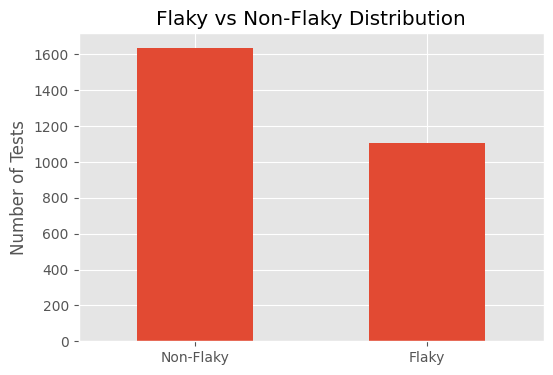

In [8]:
label_counts = (
    df["isFlaky"]
    .replace({False: "Non-Flaky", True: "Flaky"})
    .value_counts()
)

print(label_counts)

ax = label_counts.plot(
    kind="bar",
    figsize=(6,4)
)

ax.set_title("Flaky vs Non-Flaky Distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of Tests")

plt.xticks(rotation=0)

plt.show()

issue_category
Implementation Dependent    816
Order Dependent             124
Non-Idempotent              121
Time Dependent               34
                             10
Name: count, dtype: int64


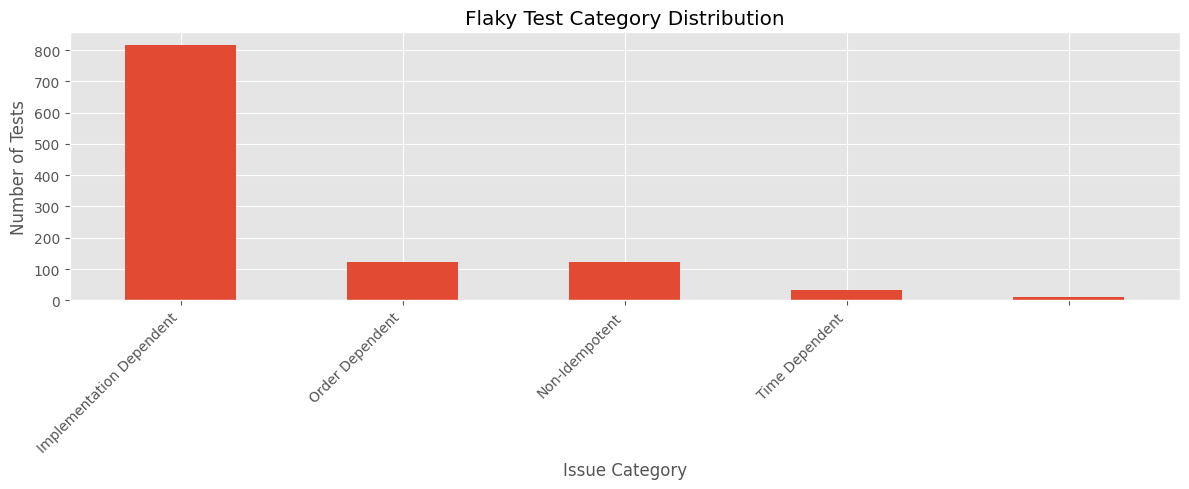

In [9]:
flaky = df[df["isFlaky"]]

category_counts = flaky["issue_category"].value_counts()

print(category_counts)

ax = category_counts.plot(
    kind="bar",
    figsize=(12,5)
)

ax.set_title("Flaky Test Category Distribution")
ax.set_xlabel("Issue Category")
ax.set_ylabel("Number of Tests")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [10]:
df[df["isFlaky"]]["issue_category"].unique()

<StringArray>
['Implementation Dependent',                         '',
          'Order Dependent',           'Non-Idempotent',
           'Time Dependent']
Length: 5, dtype: str

In [11]:
df["issue_category"] = (
    df["issue_category"]
    .replace("", "Unknown")
)

In [12]:
df[df["isFlaky"]]["issue_category"].value_counts()

issue_category
Implementation Dependent    816
Order Dependent             124
Non-Idempotent              121
Time Dependent               34
Unknown                      10
Name: count, dtype: int64

issue_category
Implementation Dependent    816
Order Dependent             124
Non-Idempotent              121
Time Dependent               34
Unknown                      10
Name: count, dtype: int64


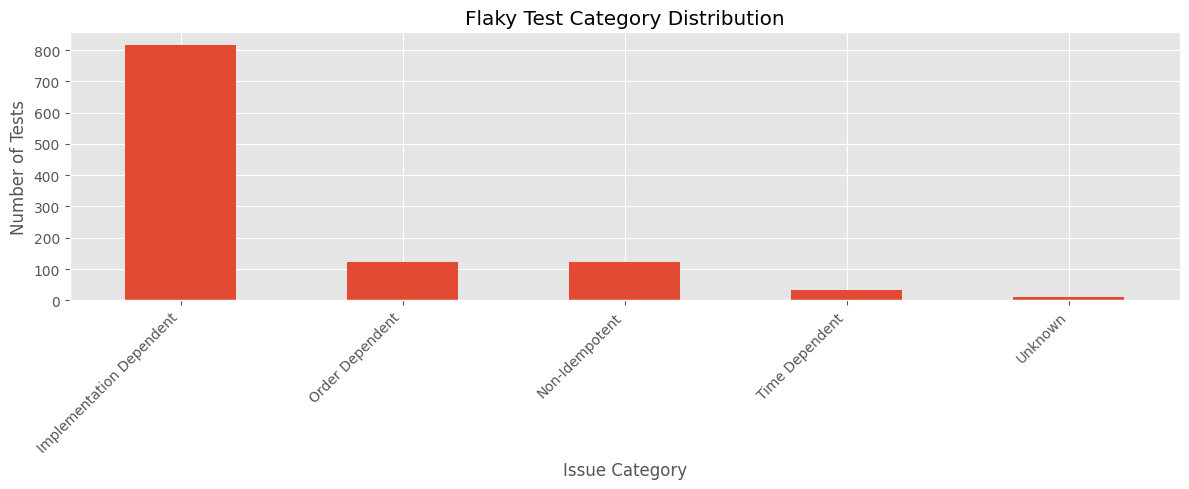

In [13]:
flaky = df[df["isFlaky"]]

category_counts = flaky["issue_category"].value_counts()

print(category_counts)

ax = category_counts.plot(
    kind="bar",
    figsize=(12,5)
)

ax.set_title("Flaky Test Category Distribution")
ax.set_xlabel("Issue Category")
ax.set_ylabel("Number of Tests")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

## 9. Context Quality-Based Dataset Balancing

To ensure the evaluation dataset contains informative samples for context-augmented prompting, a context completeness score is computed for every sample.

The score reflects the availability of contextual information used by the proposed framework:

- Helper Methods
- Code Under Test
- Failure Logs

Non-flaky samples are ranked according to this score, and only the highest-quality samples are retained until both classes contain an equal number of instances.

In [14]:
import json
import pandas as pd

In [15]:
def has_content(value):

    # Returns True if a context field contains meaningful content.


    if pd.isna(value):
        return False

    if isinstance(value, str):

        value = value.strip()

        if value == "":
            return False

        try:
            parsed = json.loads(value)

            if isinstance(parsed, (list, dict)):
                return len(parsed) > 0

        except Exception:
            return True

        return True

    if isinstance(value, (list, dict)):
        return len(value) > 0

    return True

In [16]:
df["has_helper_methods"] = df["helper_methods_json"].apply(has_content)

df["has_code_under_test"] = df["code_under_test_json"].apply(has_content)

df["has_failure_log"] = df["failure_log"].apply(has_content)

In [17]:
df["context_score"] = (
      df["has_helper_methods"].astype(int) * 2
    + df["has_code_under_test"].astype(int) * 2
    + df["has_failure_log"].astype(int)
)

In [18]:
df["context_score"].value_counts().sort_index()

context_score
1       4
2      24
3    1307
4      34
5    1372
Name: count, dtype: int64

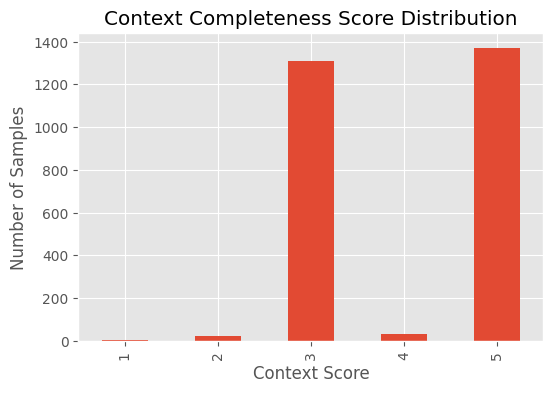

In [19]:
import matplotlib.pyplot as plt

df["context_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Context Completeness Score Distribution")
plt.xlabel("Context Score")
plt.ylabel("Number of Samples")

plt.show()

In [20]:
flaky_df = df[df["isFlaky"]]

non_flaky_df = df[~df["isFlaky"]]

In [21]:
non_flaky_df = non_flaky_df.sort_values(
    by="context_score",
    ascending=False
)

In [22]:
# Number of flaky tests
target_size = len(flaky_df)

# Keep only the highest context-score non-flaky tests
balanced_non_flaky = non_flaky_df.head(target_size)

In [23]:
print(f"Flaky Tests: {len(flaky_df)}")
print(f"Selected Non-Flaky Tests: {len(balanced_non_flaky)}")

Flaky Tests: 1105
Selected Non-Flaky Tests: 1105


In [24]:
balanced_df = pd.concat(
    [flaky_df, balanced_non_flaky],
    ignore_index=True
)

In [25]:
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [26]:
balanced_df["isFlaky"].value_counts()

isFlaky
True     1105
False    1105
Name: count, dtype: int64

In [27]:
print("Original Non-Flaky Context Score Distribution")
print(non_flaky_df["context_score"].value_counts().sort_index())

Original Non-Flaky Context Score Distribution
context_score
3    715
5    921
Name: count, dtype: int64


In [28]:
print("Selected Non-Flaky Context Score Distribution")
print(balanced_non_flaky["context_score"].value_counts().sort_index())

Selected Non-Flaky Context Score Distribution
context_score
3    184
5    921
Name: count, dtype: int64


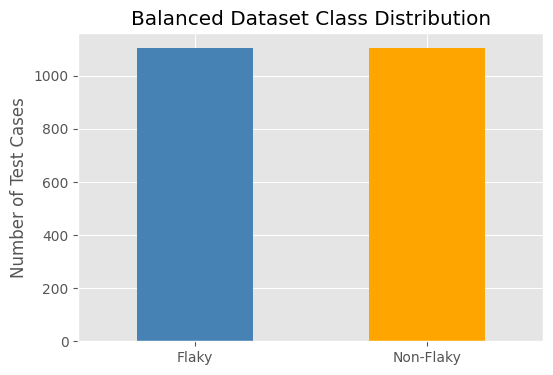

In [29]:
balanced_counts = (
    balanced_df["isFlaky"]
    .replace({False: "Non-Flaky", True: "Flaky"})
    .value_counts()
)

plt.figure(figsize=(6,4))

balanced_counts.plot(
    kind="bar",
    color=["steelblue", "orange"]
)

plt.title("Balanced Dataset Class Distribution")
plt.xlabel("")
plt.ylabel("Number of Test Cases")
plt.xticks(rotation=0)

plt.show()

In [30]:
comparison = pd.DataFrame({
    "Original": non_flaky_df["context_score"].value_counts().sort_index(),
    "Balanced": balanced_non_flaky["context_score"].value_counts().sort_index()
}).fillna(0)

comparison

,Original,Balanced
context_score,,
3,715,184
5,921,921


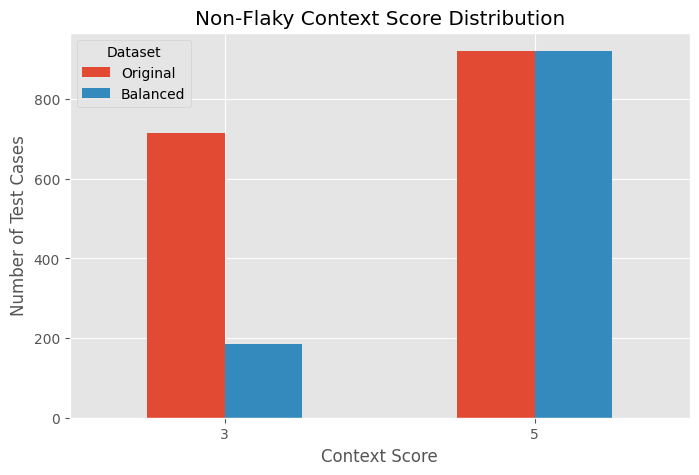

In [31]:
comparison.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Non-Flaky Context Score Distribution")
plt.xlabel("Context Score")
plt.ylabel("Number of Test Cases")
plt.xticks(rotation=0)

plt.legend(title="Dataset")

plt.show()

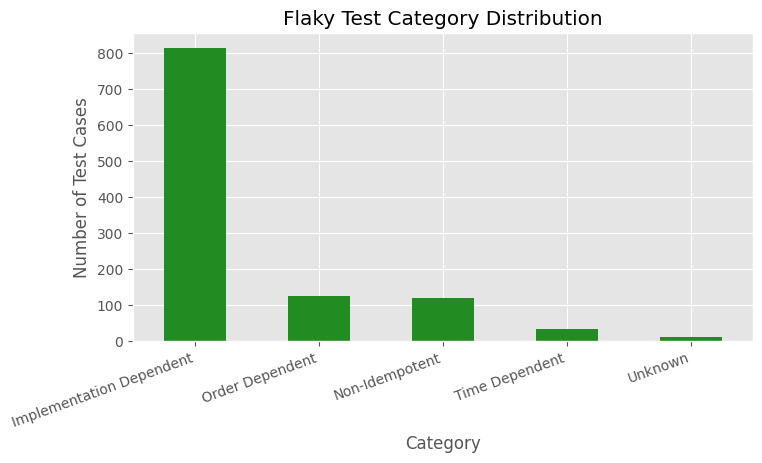

In [32]:
category_counts = (
    balanced_df[balanced_df["isFlaky"]]["issue_category"]
    .value_counts()
)

plt.figure(figsize=(8,4))

category_counts.plot(
    kind="bar",
    color="forestgreen"
)

plt.title("Flaky Test Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Test Cases")

plt.xticks(rotation=20, ha="right")

plt.show()

In [33]:
print("=" * 50)
print("Balanced Dataset Summary")
print("=" * 50)

print(f"Original Dataset Size : {len(df)}")
print(f"Balanced Dataset Size : {len(balanced_df)}")
print(f"Flaky Tests           : {len(flaky_df)}")
print(f"Non-Flaky Tests       : {len(balanced_non_flaky)}")
print(f"Removed Non-Flaky     : {len(non_flaky_df) - len(balanced_non_flaky)}")

print("\nClass Distribution")
print(balanced_df["isFlaky"].value_counts())

Balanced Dataset Summary
Original Dataset Size : 2741
Balanced Dataset Size : 2210
Flaky Tests           : 1105
Non-Flaky Tests       : 1105
Removed Non-Flaky     : 531

Class Distribution
isFlaky
True     1105
False    1105
Name: count, dtype: int64


In [35]:
OUTPUT_PATH = Path("../../datasets/evaluation_dataset.jsonl")

balanced_df.to_json(
    OUTPUT_PATH,
    orient="records",
    lines=True
)

print(f"Balanced dataset saved to: {OUTPUT_PATH}")

Balanced dataset saved to: ..\..\datasets\evaluation_dataset.jsonl
